In [1]:
# 1. decoding:within versus across session decoding comparisons (of estimates: E)
#       corr. with shift in prior (risky/safe/); stress-level (auc)
# 2. encoding: parameter comparison (ses1 vs. 2)
import pandas as pd
import os.path as op
import numpy as np
from os import listdir
#import pingouin
import matplotlib.pyplot as plt
import seaborn as sns


bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'
subFolders = [f[4:] for f in listdir(bids_folder) if f[0:3] == 'sub']

from stress_risk.utils.data import get_data
df = get_data(bids_folder = bids_folder_behav)
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)


/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
# decoding: look only at session 2, compare within with across sessions E (numerosity estimate)

Es_within = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/within_ses_decodedE.csv')
Es_across = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/across_ses_decodedE.csv')

Es_within = Es_within.set_index(['subject', 'trial_nr', 'session']).rename(mapper={'E':'E_w', 'sd':'sd_w'}, axis=1).xs(2,0,'session')
Es_across = Es_across.set_index(['subject', 'trial_nr']).rename(mapper={'E':'E_a', 'sd':'sd_a'}, axis=1)


In [30]:
from stress_risk.utils.data import add_cond2df

Es = Es_within.join(Es_across).set_index('risky_first', append=True)
Es = add_cond2df(Es)

#len(Es.reset_index()['subject'].unique()) # sub-1 ses-2 missing! 
Es['E_dif'] = Es['E_a'] - Es['E_w']
Es

E_w      sd_w       E_a      sd_a    n1  \
subject trial_nr risky_first                                                 
2       1        False        3.630729  0.237235  3.227458  0.480335  10.0   
                 False        3.630729  0.237235  3.227458  0.480335  10.0   
        2        False        3.215811  0.250970  3.158594  0.693151  14.0   
                 False        3.215811  0.250970  3.158594  0.693151  14.0   
        3        False        3.268363  0.630426  3.231419  0.480769  14.0   
...                                ...       ...       ...       ...   ...   
61      118      True         3.930218  0.220174  2.644663  0.140344  34.0   
        119      True         1.928028  0.033986  2.436559  0.227761  34.0   
                 True         1.928028  0.033986  2.436559  0.227761  34.0   
        120      True         4.440225  0.185782  3.617215  0.254384  42.0   
                 True         4.440225  0.185782  3.617215  0.254384  42.0   

                              group    log_n1     E_dif  
subject trial_nr risky_first                             
2       1        False            0  2.302585 -0.403270  
                 False            0  2.302585 -0.403270  
        2        False            0  2.639057 -0.057217  
                 False            0  2.639057 -0.057217  
        3        False            0  2.639057 -0.036944  
...                             ...       ...       ...  
61      118      True             0  3.526361 -1.285555  
        119      True             0  3.526361  0.508531  
                 True             0  3.526361  0.508531  
        120      True             0  3.737670 -0.823009  
                 True             0  3.737670 -0.823009  

[11651 rows x 8 columns]

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-4.46365,91.797963,two-sided,0.000023,"[-0.19, -0.07]",0.905211,851.152,0.993328


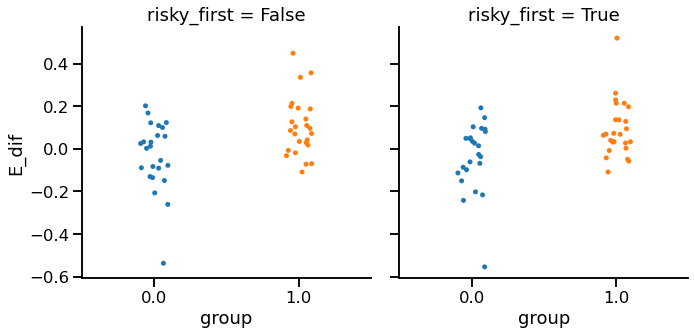

In [66]:
temp = Es.groupby(['subject', 'risky_first']).mean().set_index('group', append=True) # , 'risky_first'
sns.set_context('talk')
sns.catplot(data=temp.reset_index(), x='group', y='E_dif',  col='risky_first') #kind='bar',
pingouin.anova(data=temp.reset_index(), dv='E_dif', between='group')
pingouin.ttest(temp.xs(0,0,'group')['E_dif'], temp.xs(1,0,'group')['E_dif'])

# pingouin.corr(Es['E_w'], Es['E_a']) # do correlate with each other

In [5]:
# correlation with prior shift from NLC model

name_prior = 'risky_prior'
n_model = 1
df_prior_shift = pd.read_csv(f'/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_change_{name_prior}_model-{n_model}.csv')
df_prior_shift = df_prior_shift.set_index('subject')


In [6]:
from utils import get_stress_level
df_auc = get_stress_level()

df = get_data(bids_folder = bids_folder_behav)
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)
df_prior_shift = df_prior_shift.join(group_mapping).join(df_auc)

In [10]:
# linear model, only works with behav_fit environment
import bambi

formulae = 'risky_prior_mu ~ 0 + AUC*group'
model = bambi.Model(formulae, data=df_prior_shift.dropna())
traces = model.fit(init='adapt_diag', target_accept=0.9, draws=1000, tune=1000)

Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [AUC, group, AUC:group, risky_prior_mu_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


Text(0.5, 1.0, 'p(beta)>0 = 0.412')

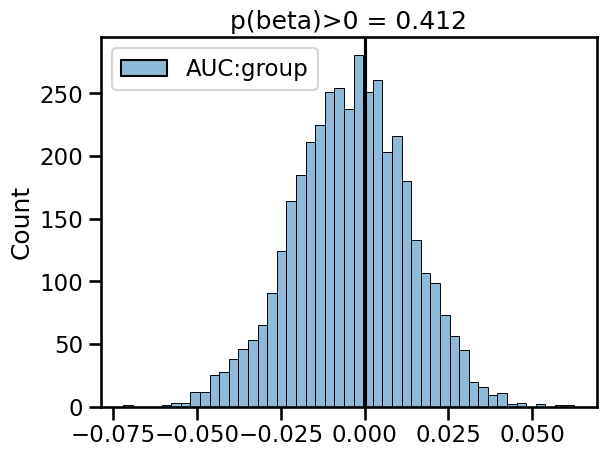

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

post = traces.posterior['AUC:group'].to_dataframe() # 'group', 'AUC:group', AUC
p = np.round(np.mean(post>0), 3)[0]
sns.set_context('talk')
sns.histplot(post)
plt.axvline(0, c='black')
plt.title(f'p(beta)>0 = {p}')

In [8]:
pingouin.mediation_analysis(df_prior_shift,x='group',m='AUC',y='risky_prior_mu')

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,AUC ~ X,4.795067,0.896360,2.557270e-06,2.991823,6.598310,Yes
1,Y ~ AUC,0.036976,0.008587,8.393367e-05,0.019700,0.054251,Yes
2,Total,0.476016,0.037770,1.106048e-16,0.400032,0.551999,Yes
3,Direct,0.480592,0.048413,5.137811e-13,0.383141,0.578043,Yes
4,Indirect,-0.004577,0.034644,9.560000e-01,-0.085419,0.052858,No


In [ ]:
df_Es = Es.groupby(['subject']).mean()
df_comb = df_prior_shift.join(df_Es[['E_dif', 'group']]).set_index('group', append=True)

Text(0.5, 1.0, 'group all \n r=0.25, p= 0.07908')

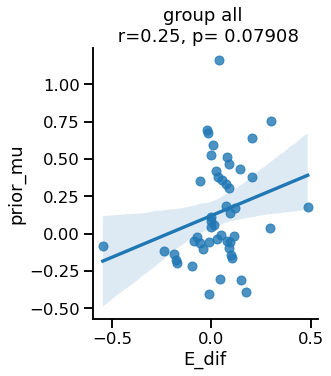

In [83]:
import matplotlib.pyplot as plt

gr = 'all'
t = df_comb#.xs(gr,0,'group')
sns.lmplot(data=t.reset_index() , x='E_dif', y = f'{name_prior}_mu') #, hue='group'
cor = pingouin.corr(t['E_dif'], t[f'{name_prior}_mu'])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.title(f'group {gr} \n r={r_}, p= {p}')


In [ ]:
from utils import get_stress_level
df_auc = get_stress_level()

df_comb = df_comb.join(df_auc)

In [ ]:
gr = 'all'
t = df_comb#.xs(gr,0,'group')

cor = pingouin.corr(t['AUC'], t[f'{name_prior}_mu'])
r_, p = np.round(cor['r'][0], 2), np.round(cor['p-val'][0], 5)
sns.lmplot(data=t.reset_index() , x='AUC', y = f'{name_prior}_mu').set(title=f'group {gr} \n r={r_}, p= {p}') #, hue='group'

cor = pingouin.corr(t['AUC'], t['E_dif'])
r_, p = np.round(cor['r'][0], 2), np.round(cor['p-val'][0], 5)
sns.lmplot(data=t.reset_index() , x='AUC', y = 'E_dif', hue='group').set(title=f'group {gr} \n r={r_}, p= {p}') #, hue='group'


In [2]:
# 2. encoding: compare nPRF between sessions between groups

roi='NPC_R'
key = 'encoding_model.cv.denoise.retroicor'
session1 = 1

# prep. col names for df in next step
parameter_names = ['mu','sd','amplitude','baseline']
d1 = {}
for col_name in parameter_names:
    d1[col_name] = col_name  + f'_1'
d2 = {}
for col_name in parameter_names:
    d2[col_name] = col_name  + f'_2'


In [4]:
from stress_risk.utils import Subject
from nilearn import image
from nilearn.maskers import NiftiMasker
from stress_risk.utils.data import add_cond2df

pars_s = []
for subject in subFolders:
    sub = Subject(subject, bids_folder)

    # get average cv-r2 map from seesion 1 for voxel selection
    fn = op.join(bids_folder, 'derivatives', key, f'sub-{sub.subject}', f'ses-{session1}','func', f'sub-{sub.subject}_ses-{session1}_desc-cvr2.optim_space-T1w_pars.nii.gz')
    im_cvr2 = image.load_img(fn)

    mask = sub.get_volume_mask(roi=roi, session=1, epi_space=True) # anat from session1
    masker = NiftiMasker(mask_img=mask)

    cv_r2 = pd.DataFrame(masker.fit_transform(im_cvr2))
    r2_mask = cv_r2 > 0.0
    r2_mask = r2_mask.to_numpy().T
    n_voxels = r2_mask.sum()

    # get params
    pars1 = sub.get_prf_parameters_volume(session=1, cross_validated=False,denoise=True, retroicor=True,smoothed=True, pca_confounds=False,roi=roi)
    pars1 =pars1.rename(mapper=d1,axis=1)
    pars1 = pars1[r2_mask] #

    pars2 = sub.get_prf_parameters_volume(session=2, cross_validated=False,denoise=True, retroicor=True,smoothed=True, pca_confounds=False,roi=roi)
    pars2 = pars2.rename(mapper=d2,axis=1)
    pars2 = pars2[r2_mask] #

    pars = pd.concat([pars1,pars2],axis=1)
    pars = pars.reset_index().rename(mapper={'index':'voxel_n'},axis=1)
    pars['subject'] = int(sub.subject)

    pars = pars.set_index(['subject','voxel_n'])
    pars_s.append(pars)

pars_s = pd.concat(pars_s)  
pars_s = add_cond2df(pars_s)
      

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/image/image.py:756: FutureWarning: Image data has type int64, which may cause incompatibilities with other tools. This will error in NiBabel 5.0. This warning can be silenced by passing the dtype argument to Nifti1Image().
  return klass(data, affine, header=header)
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/image/image.py:756: FutureWarning: Image data has type int64, which may cause incompatibilities with other tools. This will error in NiBabel 5.0. This warning can be silenced by passing the dtype argument to Nifti1Image().
  return klass(data, affine, header=header)
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/image/image.py:756: FutureWarning: Image data has type int64, which may cause incompatibilities with other tools. This will error in NiBabel 5.0. This warning can be silenced by passing the dtype argument to Nifti1Image().
  retu

In [5]:
pars_s['mu_dif'] = pars_s['mu_2'] - pars_s['mu_1']
pars_s['sd_dif'] = pars_s['sd_2'] - pars_s['sd_1']
pars_s['amplitude_dif'] = pars_s['amplitude_2'] - pars_s['amplitude_1']
pars_s['baseline_dif'] = pars_s['baseline_2'] - pars_s['baseline_1']

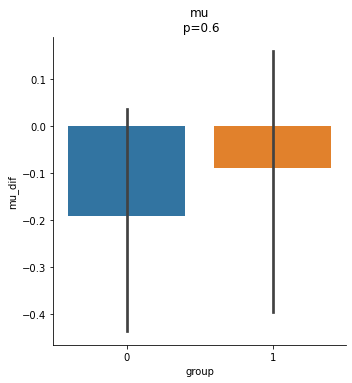

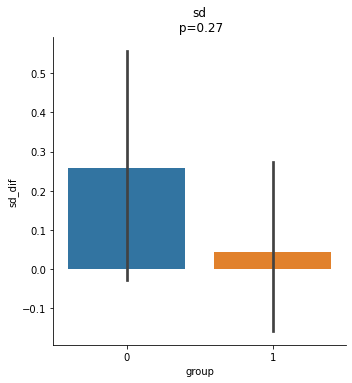

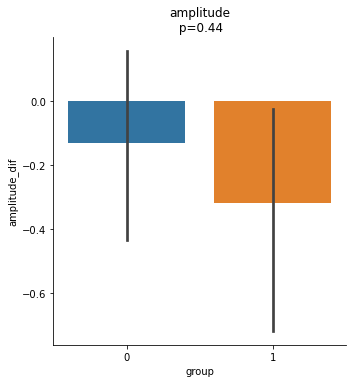

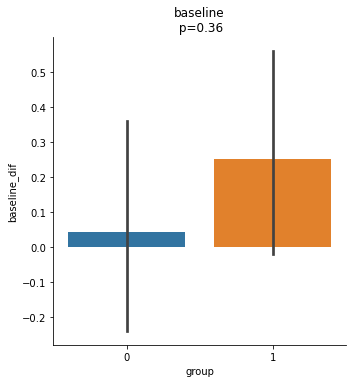

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [6]:
import pingouin

for param_name in parameter_names:
    temp = pars_s.groupby(['subject', 'group'])[[f'{param_name}_dif']].mean()
    ttest = pingouin.ttest(temp.xs(0,0,'group')[f'{param_name}_dif'], temp.xs(1,0,'group')[f'{param_name}_dif'])
    ttest_pval = np.round(ttest['p-val'][0],2)
    sns.catplot(data=temp.reset_index(), y = f'{param_name}_dif', x='group', kind='bar').set(title=f'{param_name}\n p={ttest_pval}')

In [7]:
# compare distributions
from scipy.stats import ks_2samp

p_vals = []
subs = []
for sub in subFolders:
    pars = pars_s.xs(int(sub),0,'subject')
    ks_test = ks_2samp(pars['mu_1'], pars['mu_2']) #Kolmogorov-Smirnov test
    p_vals.append(ks_test[1])
    subs.append(int(sub))

In [9]:
df_ks = pd.concat([pd.Series(subs,name='subject'),pd.Series(p_vals,name='ks_pval')], axis=1).set_index('subject')
df_ks = df_ks.join(group_mapping).set_index('group',append=True)
df_ks['log(pval)']=np.log(df_ks['ks_pval'])

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-1.493227,48,two-sided,0.141922,"[-0.25, 0.04]",0.422348,0.7,0.310057


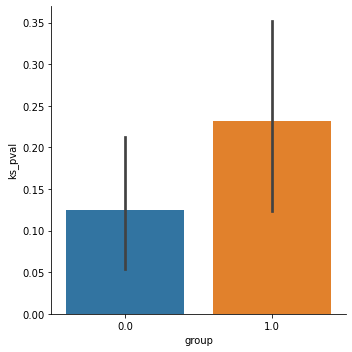

In [10]:
param = 'ks_pval' #'log(pval)'#
sns.catplot(data =df_ks.reset_index(),y=param, x='group', kind='bar')
ttest = pingouin.ttest(df_ks.xs(0,0,'group')[param], df_ks.xs(1,0,'group')[param])
ttest
# larger p-val = the more similar distributions ()

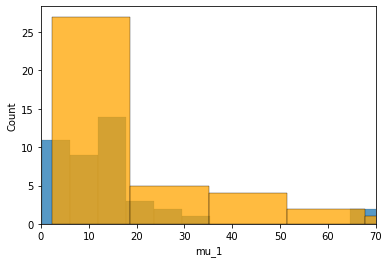

In [11]:
# distributions
pars = pars_s.xs(1,0,'subject')
pars['mu_1']

sns.histplot(np.exp(pars['mu_1']), label='mu session 1')
sns.histplot(np.exp(pars['mu_2']), color='orange', label='mu session 2')
plt.xlim([0,70])
plt.show()

In [ ]:

r_mus = pars_s.groupby(['subject', 'group']).apply(lambda d: pingouin.corr(d['mu_1'], d['mu_2']))

sns.lmplot(data=t,x='mu_1', y='mu_2')

,Source,ddof1,ddof2,F,p-unc,np2
0,group,1,48,0.683778,0.412381,0.014045


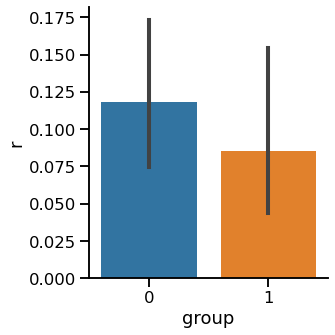

In [128]:
sns.catplot(data=r_mus.reset_index(),y='r',x='group', kind='bar')
pingouin.anova(data=r_mus.reset_index(),dv='r',between='group')